In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import joblib
import os

In [2]:
df = pd.read_csv(r"D:\Projects\Flight-app\Clean_Dataset.csv")

In [3]:
df.shape

(300153, 12)

In [4]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (300153, 12)

Columns: ['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']

Data types:
 Unnamed: 0            int64
airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

Missing values:
 Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


In [6]:
print("Airlines:", df['airline'].unique())
print("Source cities:", df['source_city'].unique())
print("Destination cities:", df['destination_city'].unique())
print("Stops:", df['stops'].unique())
print("Class:", df['class'].unique())
print("Departure times:", df['departure_time'].unique())
#checking unique values for encoding

Airlines: ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
Source cities: ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
Destination cities: ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
Stops: ['zero' 'one' 'two_or_more']
Class: ['Economy' 'Business']
Departure times: ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']


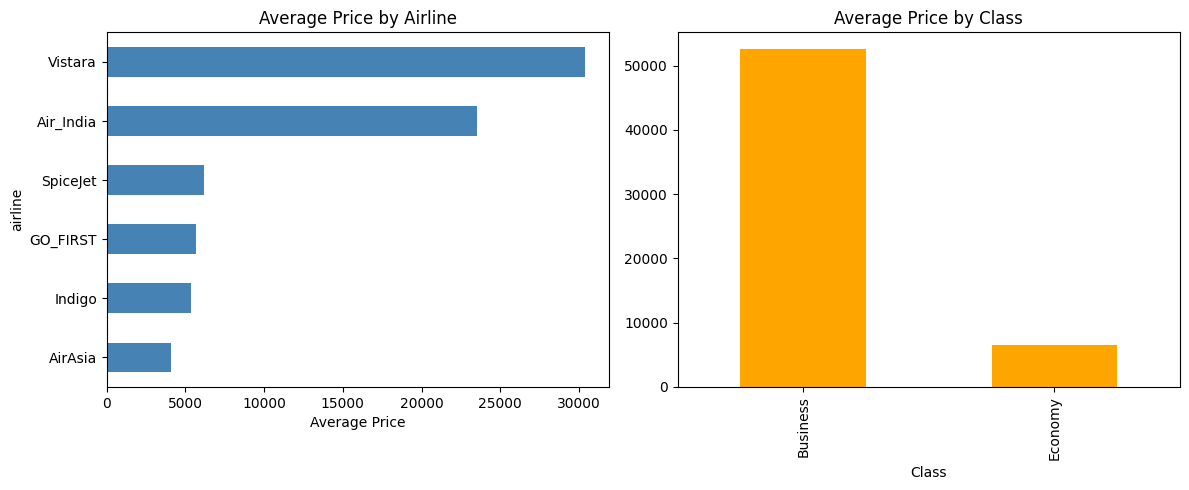

In [7]:
plt.figure(figsize=(12, 5))

# airline vs price
plt.subplot(1, 2, 1)
df.groupby('airline')['price'].mean().sort_values().plot(kind='barh', color='steelblue')
plt.title('Average Price by Airline')
plt.xlabel('Average Price')

# class vs price
plt.subplot(1, 2, 2)
df.groupby('class')['price'].mean().plot(kind='bar', color='orange')
plt.title('Average Price by Class')
plt.xlabel('Class')

plt.tight_layout()
plt.show()

#comparing prices across airlines and classes

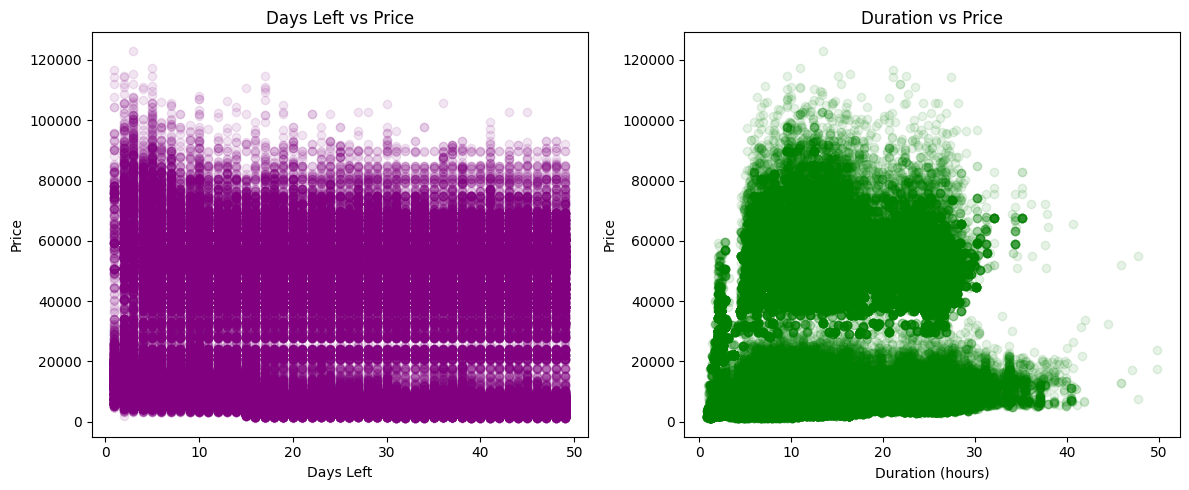

In [8]:
plt.figure(figsize=(12, 5))

# days left vs price
plt.subplot(1, 2, 1)
plt.scatter(df['days_left'], df['price'], alpha=0.1, color='purple')
plt.title('Days Left vs Price')
plt.xlabel('Days Left')
plt.ylabel('Price')

# duration vs price
plt.subplot(1, 2, 2)
plt.scatter(df['duration'], df['price'], alpha=0.1, color='green')
plt.title('Duration vs Price')
plt.xlabel('Duration (hours)')
plt.ylabel('Price')

plt.tight_layout()
plt.show()
#checking relationship between numeric columns and price

In [9]:
df = df.drop(['Unnamed: 0', 'flight'], axis=1)
#dropping Unnamed:0 - just index
#dropping flight - too many unique flight numbers
#not useful for prediction
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('price', axis=1),
    df['price'],
    test_size=0.2,
    random_state=0
)
#price is target column
#everything else is input
#80% training, 20% testing
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (240122, 9)
X_test shape: (60031, 9)


In [11]:
transformer = ColumnTransformer(transformers=[

    # OrdinalEncoding - columns with order!
    ('oe', OrdinalEncoder(categories=[
        ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night'],  # departure_time
        ['zero', 'one', 'two_or_more'],  # stops
        ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night'],  # arrival_time
        ['Economy', 'Business']  # class
    ]), ['departure_time', 'stops', 'arrival_time', 'class']),
    #departure_time, arrival_time - morning to night has order
    #stops - zero < one < two_or_more has order
    #class - Economy < Business has order

    # OneHotEncoding - no order between cities/airlines!
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
     ['airline', 'source_city', 'destination_city']),
    #airline - no order between airlines
    #cities - no order between cities

    # StandardScaler - numeric columns
    ('ss', StandardScaler(),
     ['duration', 'days_left'])
    #scaling numeric columns to same range

], remainder='drop')
#remainder='drop' removes any leftover columns

In [12]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)
#fit only on training data!
#transform both train and test
print("Shape after transformation:", X_train_transformed.shape)

Shape after transformation: (240122, 21)


In [13]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=0)
}
#comparing 3 different models
#Linear Regression - simple straight line prediction
#Decision Tree - splits data into branches
#Random Forest - many trees voting together

results = {}
for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    y_pred = model.predict(X_test_transformed)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = {'R2 Score': round(r2, 3), 'MAE': round(mae, 2)}
    print(f"{name}: R2={r2:.3f}, MAE={mae:.2f}")

#R2 Score - closer to 1.0 = better model
#MAE - Mean Absolute Error - lower = better

Linear Regression: R2=0.910, MAE=4488.30
Decision Tree: R2=0.961, MAE=2479.58
Random Forest: R2=0.986, MAE=1064.81


In [14]:
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df)
#comparing all models in a table


Model Comparison:
                   R2 Score      MAE
Linear Regression     0.910  4488.30
Decision Tree         0.961  2479.58
Random Forest         0.986  1064.81


In [15]:
# get feature names after transformation
ohe_features = transformer.named_transformers_['ohe'].get_feature_names_out(
    ['airline', 'source_city', 'destination_city']
)

# all column names after transformation
all_columns = (
    ['departure_time', 'stops', 'arrival_time', 'class']  # ordinal
    + list(ohe_features)  # onehot
    + ['duration', 'days_left']  # scaled
)

# convert to dataframe
X_train_df = pd.DataFrame(X_train_transformed, columns=all_columns)
X_train_df.head()

,departure_time,stops,arrival_time,class,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,...,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,duration,days_left
0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.979539,1.325193
1,0.0,1.0,4.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.468577,-0.517462
2,3.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-1.398453,1.177781
3,5.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.911160,-0.222637
4,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.606060,0.882956


In [16]:
# Test Random Forest file size with joblib compression
rf_test = RandomForestRegressor(n_estimators=100, random_state=0)
rf_test.fit(X_train_transformed, y_train)

joblib.dump(rf_test, 'rf_test_compressed.pkl', compress=3)

print(f"RF size (no compression):   {os.path.getsize('rf_test.pkl')/1024/1024:.2f} MB")
print(f"RF size (compress=3):       {os.path.getsize('rf_test_compressed.pkl')/1024/1024:.2f} MB")

RF size (no compression):   893.76 MB
RF size (compress=3):       177.77 MB


In [17]:
model_pipe = Pipeline(steps=[
    ('preprocessor', transformer),
    ('model', RandomForestRegressor(n_estimators=100, random_state=0))
])
print("Pipeline created!")

Pipeline created!


In [18]:
# sample 50K rows to save time
X_sample = X_train.sample(50000, random_state=0)
y_sample = y_train.loc[X_sample.index]

cv_scores = cross_val_score(
    estimator=model_pipe,
    X=X_sample,
    y=y_sample,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

print("CV Scores for each fold:", cv_scores)
print("Mean CV R2 Score:", round(np.mean(cv_scores), 3))
print("Std Dev:", round(np.std(cv_scores), 3))
# lower std = more stable model

CV Scores for each fold: [0.97924069 0.97944338 0.97888328 0.97914585 0.97882343]
Mean CV R2 Score: 0.979
Std Dev: 0.0


In [19]:
grid_search = GridSearchCV(
    estimator=model_pipe,
    param_grid=params,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_sample, y_sample)

print("Best Params:", grid_search.best_params_)
print("Best CV R2 Score:", round(grid_search.best_score_, 3))

best_model = grid_search.best_estimator_

y_pred_test  = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

print("Train R2 Score:", round(r2_score(y_train, y_pred_train), 3))
print("Test  R2 Score:", round(r2_score(y_test,  y_pred_test),  3))
print("Test  MAE     :", round(mean_absolute_error(y_test, y_pred_test), 2))

params = {
    'model__n_estimators':      [50, 80],       # fewer trees = smaller file
    'model__max_depth':         [8, 10, 12],    # shallower trees = smaller file
    'model__min_samples_leaf':  [5, 10, 20],    # bigger leaves = fewer nodes = smaller file
}

# After fitting, save with stronger compression:
joblib.dump(best_model, 'flight_model.pkl', compress=('gzip', 9))
joblib.dump(transformer, 'flight_transformer.pkl', compress=('gzip', 9))

NameError: name 'params' is not defined

In [ ]:
best_model = grid_search.best_estimator_

y_pred_test  = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

print("Train R2 Score:", round(r2_score(y_train, y_pred_train), 3))
print("Test  R2 Score:", round(r2_score(y_test,  y_pred_test),  3))
print("Test  MAE     :", round(mean_absolute_error(y_test, y_pred_test), 2))

In [ ]:
results_gs = pd.DataFrame(grid_search.cv_results_)
results_gs[['param_model__max_depth', 'param_model__min_samples_split',
            'mean_train_score', 'mean_test_score', 'rank_test_score']]\
    .sort_values('rank_test_score')

In [ ]:
# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, color='steelblue', s=5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title('Actual vs Predicted Flight Price')
plt.legend()
plt.tight_layout()
plt.show()
# points closer to red line = better predictions

In [ ]:
# Residual Plot (prediction errors)
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 4))
plt.scatter(y_pred_test, residuals, alpha=0.3, color='purple', s=5)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted Price (₹)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()
# residuals scattered randomly around 0 = good model
# patterns in residuals = model is missing something

In [ ]:
# Feature Importance
best_rf = best_model.named_steps['model']
preprocessor = best_model.named_steps['preprocessor']

# get feature names
ohe_features = preprocessor.named_transformers_['ohe']\
    .get_feature_names_out(['airline', 'source_city', 'destination_city'])

all_columns = (
    ['departure_time', 'stops', 'arrival_time', 'class']
    + list(ohe_features)
    + ['duration', 'days_left']
)

# plot top 15 features
importance_df = pd.DataFrame({
    'Feature': all_columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()
# class and days_left should be highest importance

In [ ]:
# Save best tuned model and transformer using joblib
import joblib

joblib.dump(best_model, 'flight_model.pkl', compress=3)
joblib.dump(transformer, 'flight_transformer.pkl', compress=3)
print(f"Model size: {os.path.getsize('flight_model.pkl')/1024/1024:.2f} MB")
print(f"Transformer size: {os.path.getsize('flight_transformer.pkl')/1024/1024:.2f} MB")
print("Saved successfully with joblib!")

In [ ]:
print(transformer.feature_names_in_)
print(len(transformer.feature_names_in_))

In [ ]:
# Test with a sample row
test = pd.DataFrame([{
    'airline': 'SpiceJet',
    'source_city': 'Delhi',
    'departure_time': 'Morning',
    'stops': 'zero',
    'arrival_time': 'Afternoon',
    'destination_city': 'Mumbai',
    'class': 'Economy',
    'duration': 2.5,
    'days_left': 15
}])
print(transformer.transform(test))